In [1]:
from sklearn.datasets import fetch_openml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = fetch_openml("mtp", version=1)

df.data.head()

,oz1,oz2,oz3,oz4,oz5,oz6,oz7,oz8,oz9,oz10,...,oz193,oz194,oz195,oz196,oz197,oz198,oz199,oz200,oz201,oz202
0,0.076923,0.325000,0.035088,0.200000,0.162112,0.194562,0.003900,0.060606,0.166667,0.045872,...,0.013874,0.071602,0.056880,0.179132,0.505899,0.039213,0.091327,0.321109,0.127564,0.188387
1,0.230769,0.375000,0.042105,0.333333,0.464191,0.622795,0.077623,0.373737,0.305556,0.192661,...,0.006342,0.186056,0.287438,0.384236,0.683820,0.326584,0.117990,0.456665,0.475618,0.401935
2,0.269231,0.437500,0.052632,0.333333,0.506556,0.531840,0.054374,0.212121,0.333333,0.229358,...,0.005018,0.179544,0.117431,0.384550,0.499219,0.204885,0.155967,0.360441,0.497968,0.407742
3,0.153846,0.357143,0.039474,0.266667,0.352880,0.394131,0.019654,0.171717,0.277778,0.091743,...,0.004801,0.091771,0.145349,0.243064,0.630533,0.023469,0.124430,0.336023,0.134458,0.252258
4,0.153846,0.357143,0.039474,0.266667,0.350523,0.320546,0.013154,0.101010,0.166667,0.110092,...,0.011166,0.130755,0.067583,0.250832,0.516053,0.111398,0.125693,0.332113,0.295913,0.253548


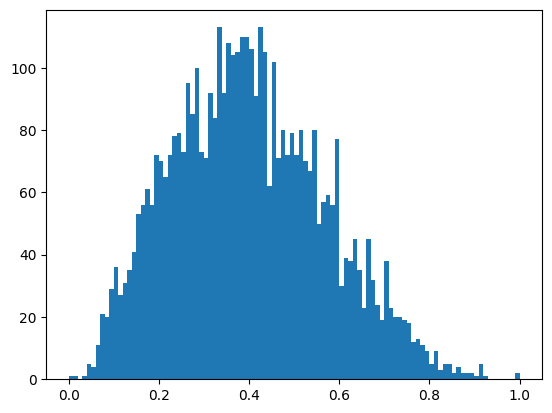

In [3]:
plt.hist(df.target, 100)
_ = plt.plot()

In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.data, df.target, test_size=0.25, random_state=42)

In [5]:
from sklearn.linear_model import LinearRegression
baseline = LinearRegression()
baseline.fit(X_train, y_train)
bl_score = baseline.score(X_test, y_test)
bl_score

-1.6511340764832814

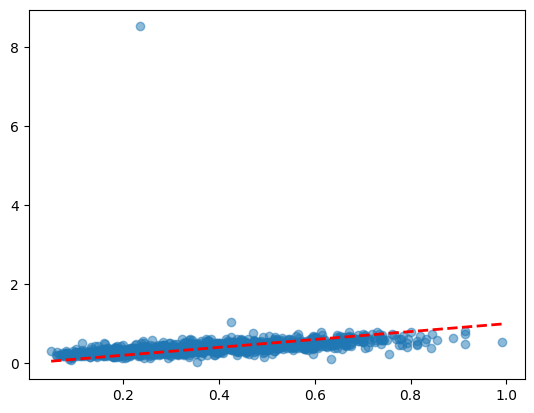

In [6]:
plt.scatter(y_test, baseline.predict(X_test), alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.show()

In [7]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=15).fit(X_train, y_train)

Text(0.5, 0, 'Feature Importance')

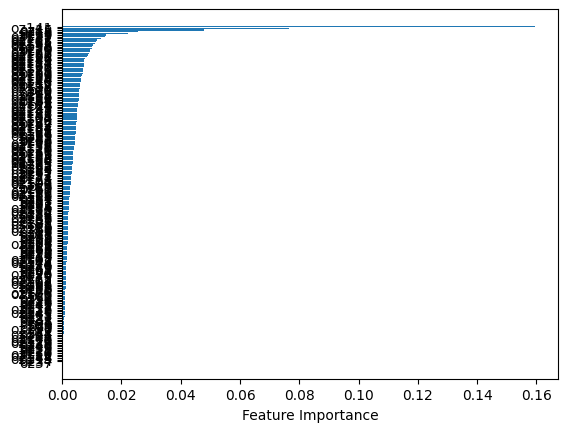

In [8]:
sort = rf.feature_importances_.argsort()
plt.barh(df.data.columns[sort], rf.feature_importances_[sort])
plt.xlabel("Feature Importance")

In [9]:
rf.feature_importances_[sort][-10:]

array([0.01138779, 0.01159682, 0.01314027, 0.01432344, 0.01478441,
       0.02235835, 0.02562617, 0.04774343, 0.07654504, 0.15940233])

In [10]:
df.data.columns[sort][-10:]

Index(['oz155', 'oz201', 'oz112', 'oz137', 'oz197', 'oz35', 'oz18', 'oz48',
       'oz15', 'oz141'],
      dtype='str')

In [11]:
trimmed = df.data[df.data.columns[sort][-20:]]
trimmed.head()

,oz149,oz138,oz161,oz180,oz162,oz179,oz20,oz56,oz158,oz198,oz155,oz201,oz112,oz137,oz197,oz35,oz18,oz48,oz15,oz141
0,0.598528,0.187757,0.382067,0.002655,0.319206,0.025609,0.000000,0.126277,0.800120,0.039213,0.752291,0.127564,0.000000,0.000000,0.505899,0.0,0.0625,0.312855,0.000000,0.041308
1,0.550919,0.148148,0.383458,0.002581,0.306084,0.024601,0.242424,0.422015,0.791224,0.326584,0.745984,0.475618,0.222222,0.278945,0.683820,0.4,0.0625,0.297041,0.282828,0.212274
2,0.562009,0.409979,0.382596,0.002722,0.406309,0.025104,0.388889,0.000000,0.798276,0.204885,0.753298,0.497968,0.000000,0.000000,0.499219,0.0,0.1250,0.288557,0.388889,0.063643
3,0.507895,0.221322,0.382776,0.002473,0.327848,0.025280,0.095238,0.000000,0.800965,0.023469,0.767469,0.134458,0.000000,0.039437,0.630533,0.1,0.0000,0.310692,0.111111,0.031193
4,0.560375,0.187757,0.383539,0.002810,0.329857,0.024934,0.260870,0.000000,0.802893,0.111398,0.741548,0.295913,0.000000,0.000000,0.516053,0.0,0.0625,0.286581,0.304348,0.063643


In [12]:
X_train, X_test, y_train, y_test = train_test_split(trimmed, df.target, test_size=0.25, random_state=42)

better = LinearRegression()
better.fit(X_train, y_train)

print(bl_score)
better.score(X_test, y_test)

-1.6511340764832814


0.3659682222987306

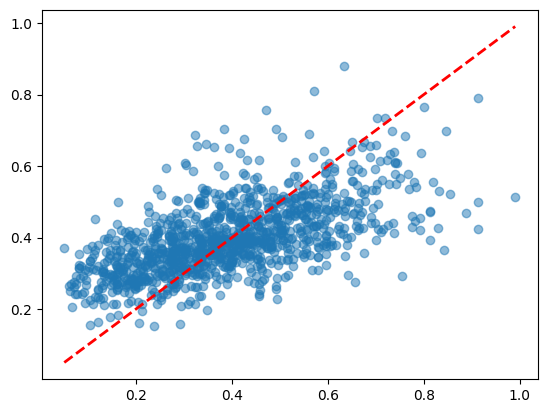

In [13]:
plt.scatter(y_test, better.predict(X_test), alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.show()

In [14]:
from sklearn.feature_selection import SelectFromModel

sfm = SelectFromModel(RandomForestRegressor(n_estimators=15)).fit(df.data, df.target)
X_trimmed = sfm.transform(df.data)
X_trimmed.shape

(4450, 57)

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X_trimmed, df.target, test_size=0.25, random_state=42)

better = LinearRegression()
better.fit(X_train, y_train)

print(bl_score)
better.score(X_test, y_test)

-1.6511340764832814


0.4387927132869668

[ 0.26715952  0.7864609   0.12467645 -0.33655094  0.19167069  0.10684705
  0.19182269 -0.29290926 -0.08990645 -0.0902217  -0.001373    0.03801799
 -0.00660664  0.1370341  -0.00756287 -0.17915598 -0.02116225  0.3836871
 -0.03178837  0.06452072 -0.01991864  0.12407061  0.05857673 -0.01051142
 -0.3607714  -0.06119314  0.0688859  -0.1974227  -0.09761702 -0.09566672
  0.06805161 -0.19147222  0.28008205 -0.26258688  0.22519536  0.42445249
 -0.47230119 -0.72361793  0.30511    -0.31049049 -0.15026688  0.22446325
  0.20357087 -0.01134624  0.41236736 -0.19719122  0.0355373   0.03703224
  0.07744929 -0.05544437  0.23021467 -0.412766    0.37898525  0.14939505
 -0.23570251 -0.07837184 -0.22290952]
0.6958882132017716
0.4387927132869668


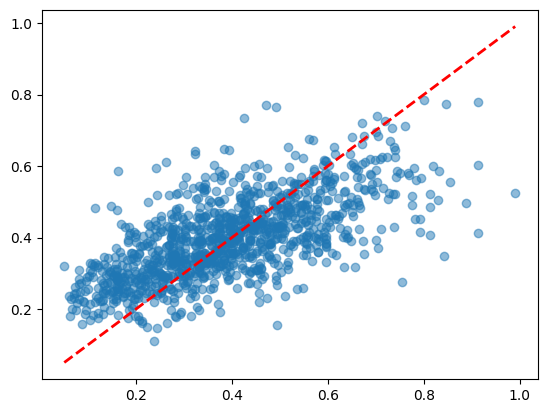

In [16]:
from sklearn.metrics import r2_score
print(better.coef_)
print(better.intercept_)
print(r2_score(y_test, better.predict(X_test)))

plt.scatter(y_test, better.predict(X_test), alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.show()


In [17]:
df = fetch_openml("balance-scale", version=1)

df.data.head()

,left-weight,left-distance,right-weight,right-distance
0,1,1,1,1
1,1,1,1,2
2,1,1,1,3
3,1,1,1,4
4,1,1,1,5


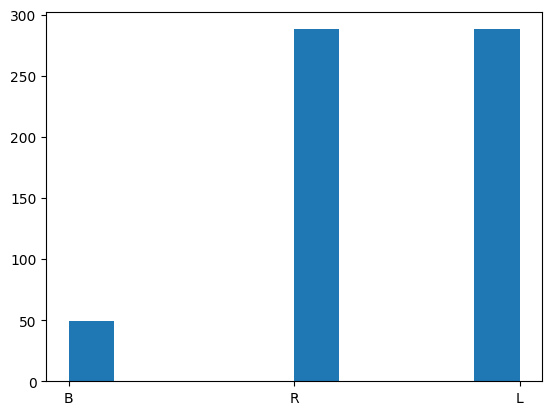

In [18]:
plt.hist(df.target)
plt.show()

In [19]:
X_train, X_test, y_train, y_test = train_test_split(df.data, df.target, test_size=0.25, random_state=42, stratify=df.target)

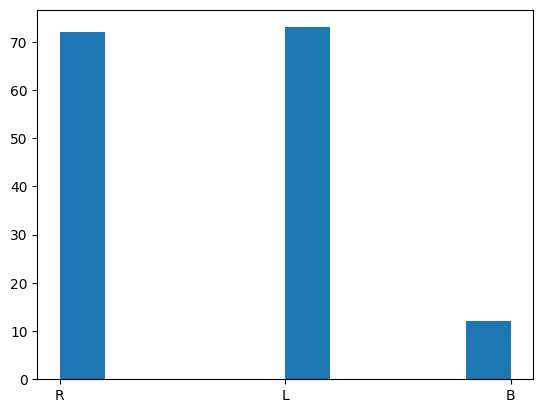

In [20]:
plt.hist(y_test)
plt.show()

In [21]:
from sklearn.linear_model import LogisticRegression
baseline = LogisticRegression()
baseline.fit(X_train, y_train)
bl_score = baseline.score(X_test, y_test)
bl_score

0.8598726114649682

In [22]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, baseline.predict(X_test)))

              precision    recall  f1-score   support

           B       0.00      0.00      0.00        12
           L       0.87      0.92      0.89        73
           R       0.86      0.94      0.90        72

    accuracy                           0.86       157
   macro avg       0.58      0.62      0.60       157
weighted avg       0.80      0.86      0.83       157



In [23]:
print(confusion_matrix(y_test, baseline.predict(X_test)))

[[ 0  6  6]
 [ 1 67  5]
 [ 0  4 68]]


In [24]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(zip(np.unique(y_train), class_weights))
class_weights

{'B': np.float64(4.216216216216216),
 'L': np.float64(0.7255813953488373),
 'R': np.float64(0.7222222222222222)}

In [25]:
weighted = LogisticRegression(class_weight=class_weights)
weighted.fit(X_train, y_train)
print(bl_score)
weighted.score(X_test, y_test)

0.8598726114649682


0.9235668789808917

In [26]:
y_train.value_counts()

class
R    216
L    215
B     37
Name: count, dtype: int64

In [27]:
X_train["target"] = y_train
oversampled = X_train[X_train.target == "B"].sample(n=216-37, replace=True, ignore_index=True)
oversampled = pd.concat([X_train, oversampled])
print(oversampled.shape)
oversampled.head()

(647, 5)


,left-weight,left-distance,right-weight,right-distance,target
262,3,1,3,3,R
401,4,2,1,2,L
174,2,2,5,5,R
81,1,4,2,2,B
36,1,2,3,2,R


In [28]:
y_train_OS = oversampled.target
X_train_OS = oversampled.drop(["target"], axis=1)

In [29]:
OSmodel = LogisticRegression()
OSmodel.fit(X_train_OS, y_train_OS)
print(bl_score)
OSmodel.score(X_test, y_test)

0.8598726114649682


0.9235668789808917

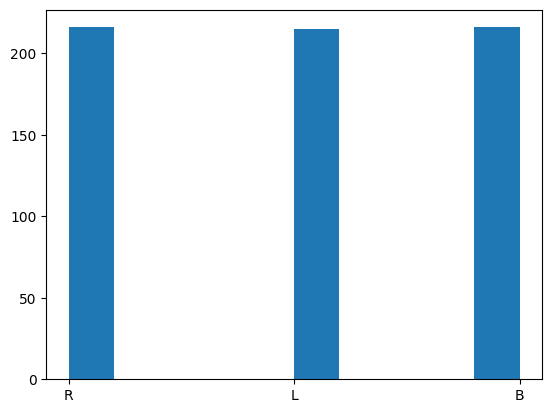

In [30]:
plt.hist(y_train_OS)
plt.show()

In [31]:
df = fetch_openml("CPMP-2015-regression", version=1)
df.data.drop(["instance_id"], inplace=True, axis=1)
df.data = pd.get_dummies(df.data)
df.data.head()

,repetition,stacks,tiers,stack.tier.ratio,container.density,empty.stack.pct,overstowing.stack.pct,overstowing.2cont.stack.pct,group.same.min,group.same.max,...,avg.l1.top.left.lg.group,cont.empty.grt.estack,pct.bottom.pct.on.top,algorithm_astar.symmulgt.transmul,algorithm_astar.symmullt.transmul,algorithm_idastar.symmulgt.transmul,algorithm_idastar.symmullt.transmul,runstatus_memout,runstatus_ok,runstatus_timeout
0,1,16,5,0.3125,0.6,0.0625,0.6250,0.909091,0,6,...,0.509615,0.1750,0.0,True,False,False,False,False,True,False
1,1,16,5,0.3125,0.6,0.0625,0.6250,0.909091,0,6,...,0.509615,0.1750,0.0,False,True,False,False,False,True,False
2,1,16,5,0.3125,0.6,0.0625,0.6250,0.909091,0,6,...,0.509615,0.1750,0.0,False,False,True,False,False,True,False
3,1,16,5,0.3125,0.6,0.0625,0.6250,0.909091,0,6,...,0.509615,0.1750,0.0,False,False,False,True,False,False,True
4,1,16,5,0.3125,0.6,0.1875,0.5625,1.000000,0,7,...,0.663462,0.3375,0.0,True,False,False,False,True,False,False


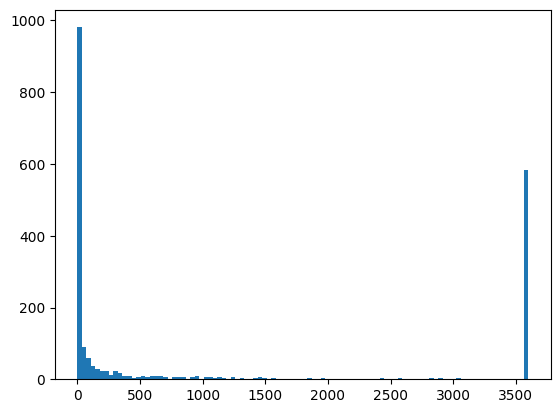

In [32]:
plt.hist(df.target, 100)
_ = plt.plot()

In [33]:
X_train, X_test, y_train, y_test = train_test_split(df.data, df.target, test_size=0.25, random_state=42)

In [34]:
from sklearn.preprocessing import KBinsDiscretizer

y_binned = KBinsDiscretizer(n_bins=5, encode="ordinal", strategy="uniform").fit_transform(pd.DataFrame(y_train))

In [35]:
y_binned

array([[4.],
       [0.],
       [4.],
       ...,
       [0.],
       [0.],
       [4.]], shape=(1581, 1))

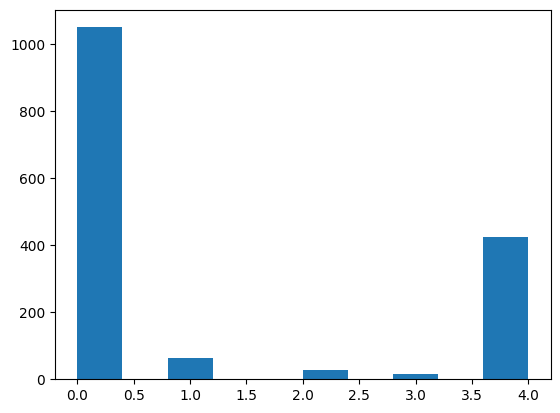

In [36]:
plt.hist(y_binned)
plt.show()

In [37]:
y_binned = KBinsDiscretizer(n_bins=5, encode="ordinal", strategy="quantile").fit_transform(pd.DataFrame(y_train))

/Users/tedvtorov/Desktop/py-proj/MISIS/misis_ml_course_sem6/venv/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/Users/tedvtorov/Desktop/py-proj/MISIS/misis_ml_course_sem6/venv/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(


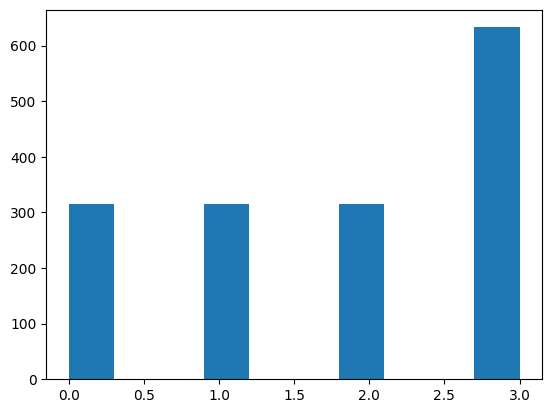

In [38]:
plt.hist(y_binned)
plt.show()

# EXTRA TASKS
# 1

In [39]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=15, random_state=42)
rf.fit(X_train, y_train)

importances = rf.feature_importances_
sorted_indices = importances.argsort()[::-1] 

In [40]:
from sklearn.linear_model import LinearRegression

num_features_list = range(1, len(sorted_indices) + 1, 1)
scores = []

for k in num_features_list:
    top_k_indices = sorted_indices[:k]
    
    X_train_k = X_train.iloc[:, top_k_indices]
    X_test_k = X_test.iloc[:, top_k_indices]
    
    model = LinearRegression()
    model.fit(X_train_k, y_train)

    score = model.score(X_test_k, y_test)
    scores.append(score)

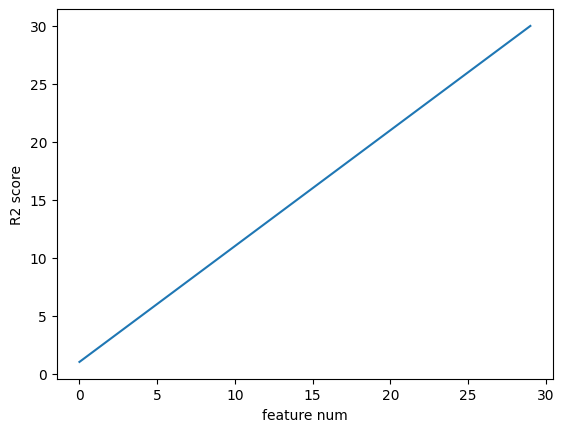

In [41]:
plt.plot(num_features_list)
plt.xlabel('feature num')
plt.ylabel('R2 score')
plt.show()

# 2

In [43]:
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.feature_selection import (
    VarianceThreshold,
    SelectKBest,
    f_regression,
    RFE,
    SequentialFeatureSelector,
    SelectFromModel
)

vt = VarianceThreshold(threshold=0.01)
X_train_vt = vt.fit_transform(X_train)
print(f"low-variance exclusion: kept {X_train_vt.shape[1]} out of {X_train.shape[1]} features")

low-variance exclusion: kept 25 out of 30 features


In [44]:
skb = SelectKBest(score_func=f_regression, k=15)
X_train_skb = skb.fit_transform(X_train, y_train)
print(f"statistical exclusion (F-test): kept {X_train_skb.shape[1]} features")


statistical exclusion (F-test): kept 15 features


In [45]:
estimator = LinearRegression()
rfe = RFE(estimator, n_features_to_select=15, step=1)
X_train_rfe = rfe.fit_transform(X_train, y_train)
print(f"recursive feature elimination: kept {X_train_rfe.shape[1]} features")


recursive feature elimination: kept 15 features


In [46]:
sfs = SequentialFeatureSelector(estimator, n_features_to_select=15, direction='forward', cv=3)
sfs.fit(X_train, y_train)
X_train_sfs = sfs.transform(X_train)
print(f"sequential feature inclusion: kept {X_train_sfs.shape[1]} features")


sequential feature inclusion: kept 15 features


In [47]:
lasso = Lasso(alpha=0.1, random_state=42)
lasso.fit(X_train, y_train)
sfm_l1 = SelectFromModel(lasso, prefit=True)
X_train_l1 = sfm_l1.transform(X_train)
print(f"L1-norm exclusion: kept {X_train_l1.shape[1]} features")

L1-norm exclusion: kept 29 features


/Users/tedvtorov/Desktop/py-proj/MISIS/misis_ml_course_sem6/venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.707e+06, tolerance: 3.824e+05
  model = cd_fast.enet_coordinate_descent(
/Users/tedvtorov/Desktop/py-proj/MISIS/misis_ml_course_sem6/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


# 3

In [48]:
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler, TomekLinks
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from collections import Counter

df_bal = fetch_openml("balance-scale", version=1)
X_train_bal, X_test_bal, y_train_bal, y_test_bal = train_test_split(
    df_bal.data, df_bal.target, test_size=0.25, random_state=42, stratify=df_bal.target
)

print(Counter(y_train_bal))


Counter({'R': 216, 'L': 215, 'B': 37})


In [52]:
ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train_bal, y_train_bal)
print(Counter(y_train_ros))

Counter({'R': 216, 'L': 216, 'B': 216})


In [53]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_bal, y_train_bal)
print(Counter(y_train_smote))

Counter({'R': 216, 'L': 216, 'B': 216})


In [54]:
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train_bal, y_train_bal)
print(Counter(y_train_rus))

Counter({'B': 37, 'L': 37, 'R': 37})


In [55]:
tl = TomekLinks()
X_train_tl, y_train_tl = tl.fit_resample(X_train_bal, y_train_bal)
print(Counter(y_train_tl))

Counter({'R': 213, 'L': 213, 'B': 37})


# 4

/Users/tedvtorov/Desktop/py-proj/MISIS/misis_ml_course_sem6/venv/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/Users/tedvtorov/Desktop/py-proj/MISIS/misis_ml_course_sem6/venv/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/Users/tedvtorov/Desktop/py-proj/MISIS/misis_ml_course_sem6/venv/lib

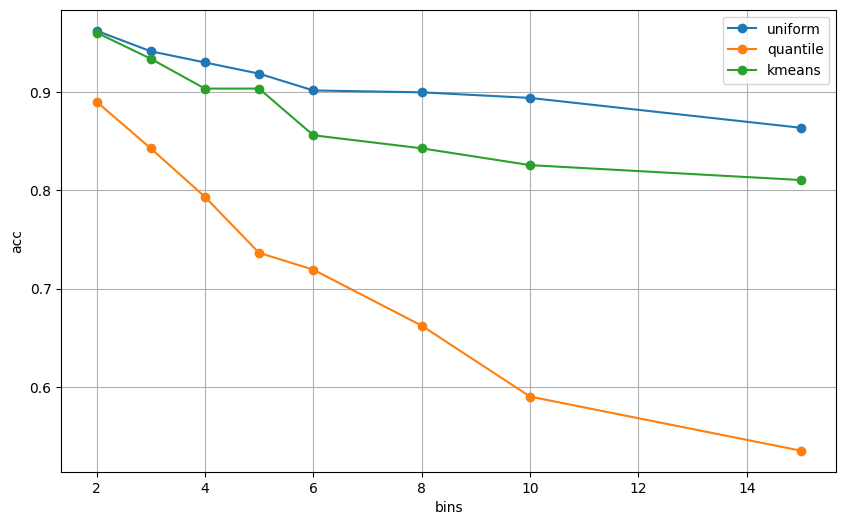

In [ ]:
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
bins_list = [2, 3, 4, 5, 6, 8, 10, 15]
strategies = ['uniform', 'quantile', 'kmeans']

results = {strategy: [] for strategy in strategies}

for strategy in strategies:
    for n_bins in bins_list:
        kbd = KBinsDiscretizer(n_bins=n_bins, encode="ordinal", strategy=strategy)
        
        y_train_binned = kbd.fit_transform(pd.DataFrame(y_train)).ravel()
        y_test_binned = kbd.transform(pd.DataFrame(y_test)).ravel()
        
        clf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
        clf.fit(X_train, y_train_binned)
        
        y_pred = clf.predict(X_test)
        acc = accuracy_score(y_test_binned, y_pred)
        results[strategy].append(acc)

plt.figure(figsize=(10, 6))
for strategy in strategies:
    plt.plot(bins_list, results[strategy], label=strategy, marker='o')

plt.xlabel('bins')
plt.ylabel('acc')
plt.grid(True)
plt.legend()
plt.show()